---
title: "Forecast Daily Spare-parts Demand with TabPFN"
description: "Compare local and grouped TabPFN regressors on realistic synthetic demand from German manufacturing plants"
icon: "chart-line"
cookbookTags:
  - time-series
  - regression
authors:
  - name: Prior Labs
    linkedin: https://www.linkedin.com/company/prior-labs
    twitter: https://twitter.com/prior_labs
---

Spare-parts demand is a panel forecasting problem: many related daily series share calendar effects and operational patterns, but each part and plant also behaves differently. In this recipe we turn daily demand into a tabular regression problem and compare three ways to share information with `TabPFNRegressor`:

- **Series by series:** one local model for each part–plant pair.
- **By product category:** one model pools related parts across plants.
- **By location:** one model pools all parts used at the same plant.

> The data in this notebook is entirely synthetic. Product names, plant locations, and quantities are illustrative and do not represent STIHL or any other company's operations.

## Setup

The example uses the standard TabPFN regressor plus pandas, scikit-learn, German public-holiday calendars, and matplotlib. A GPU is recommended, though this compact example also runs on CPU.

In [1]:
import importlib.util

required = ("tabpfn", "pandas", "sklearn", "matplotlib", "holidays")
if not all(importlib.util.find_spec(package) for package in required):
    %pip install -q tabpfn pandas scikit-learn matplotlib holidays

In [2]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", category=FutureWarning)

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from tabpfn import TabPFNRegressor

pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42

## Create realistic daily demand

We simulate six spare parts at two German plants from January 2023 through December 2024. The generator combines weekday effects, state-specific holidays, annual seasonality, scheduled maintenance campaigns, summer and Christmas shutdowns, autocorrelated operating intensity, over-dispersed counts, intermittent zeros, and rare demand spikes. These ingredients produce the mixtures of regular, noisy, and sparse series common in maintenance consumption.

In [3]:
PARTS = pd.DataFrame(
    [
        ("BRG-6204", "Deep-groove bearing 6204", "Bearings", 13.0, 0.13, 0.2),
        ("BRG-6305", "Deep-groove bearing 6305", "Bearings", 7.0, 0.16, 0.5),
        ("FLT-HYD-010", "Hydraulic filter 10 μm", "Filters", 5.0, 0.24, 2.2),
        ("FLT-AIR-220", "Air filter cartridge 220", "Filters", 8.5, 0.20, 2.6),
        ("DRV-BELT-A45", "Drive belt A45", "Drive", 6.0, 0.18, 4.0),
        ("DRV-SPR-08", "Drive sprocket 08", "Drive", 3.2, 0.27, 4.4),
    ],
    columns=["part_id", "part_name", "category", "base_rate", "annual_amp", "phase"],
)

PLANTS = pd.DataFrame(
    [
        ("Stuttgart", "BW", 1.15),
        ("Hamburg", "HH", 0.85),
    ],
    columns=["location", "state_code", "plant_factor"],
)
DATES = pd.date_range("2023-01-01", "2024-12-31", freq="D")

In [4]:
def simulate_daily_demand(seed=SEED):
    rng = np.random.default_rng(seed)
    frames = []

    for plant in PLANTS.itertuples(index=False):
        de_holidays = holidays.Germany(
            years=sorted(set(DATES.year)), subdiv=plant.state_code
        )
        for part in PARTS.itertuples(index=False):
            day = np.arange(len(DATES))
            dow = DATES.dayofweek.to_numpy()
            is_holiday = np.array([date.date() in de_holidays for date in DATES])
            is_shutdown = (
                DATES.isocalendar().week.astype(int).isin([32, 33]).to_numpy()
                | ((DATES.month == 12) & (DATES.day >= 24))
                | ((DATES.month == 1) & (DATES.day <= 2))
            )

            weekday_factor = np.array([1.12, 1.06, 1.03, 1.00, 0.84, 0.10, 0.05])[dow]
            annual = 1 + part.annual_amp * np.sin(2 * np.pi * day / 365.25 + part.phase)
            trend = 1 + rng.uniform(-0.06, 0.10) * day / len(DATES)
            campaign = np.ones(len(DATES))
            campaign_months = [3, 9] if part.category != "Bearings" else [4, 10]
            campaign[np.isin(DATES.month, campaign_months) & (DATES.day <= 7)] = 1.65

            # Slowly varying utilisation creates realistic runs of high and low demand.
            state = np.zeros(len(DATES))
            innovations = rng.normal(0, 0.075, len(DATES))
            for i in range(1, len(DATES)):
                state[i] = 0.88 * state[i - 1] + innovations[i]

            mean = (
                part.base_rate
                * plant.plant_factor
                * weekday_factor
                * annual
                * trend
                * campaign
                * np.exp(state)
            )
            mean[is_holiday] *= 0.08
            mean[is_shutdown] *= 0.18

            # Gamma-Poisson sampling gives over-dispersed integer demand.
            dispersion = 5.0
            stochastic_rate = rng.gamma(dispersion, mean / dispersion)
            demand = rng.poisson(stochastic_rate)
            if part.base_rate < 6:
                demand[rng.random(len(DATES)) < 0.18] = 0
            spikes = rng.random(len(DATES)) < 0.006
            demand[spikes] += rng.poisson(np.maximum(mean[spikes] * 3.0, 1))

            frames.append(
                pd.DataFrame(
                    {
                        "date": DATES,
                        "part_id": part.part_id,
                        "part_name": part.part_name,
                        "category": part.category,
                        "location": plant.location,
                        "state_code": plant.state_code,
                        "is_holiday": is_holiday.astype(int),
                        "is_shutdown": is_shutdown.astype(int),
                        "demand": demand.astype(int),
                    }
                )
            )

    panel = pd.concat(frames, ignore_index=True)
    panel["series_id"] = panel["part_id"] + " · " + panel["location"]
    return panel.sort_values(["series_id", "date"]).reset_index(drop=True)


panel = simulate_daily_demand()
print(f"{len(panel):,} rows | {panel['series_id'].nunique()} daily series | "
      f"{panel['date'].min().date()} to {panel['date'].max().date()}")
panel.head()

8,772 rows | 12 daily series | 2023-01-01 to 2024-12-31


,date,part_id,part_name,category,location,state_code,is_holiday,is_shutdown,demand,series_id
0,2023-01-01,BRG-6204,Deep-groove bearing 6204,Bearings,Hamburg,HH,1,1,0,BRG-6204 · Hamburg
1,2023-01-02,BRG-6204,Deep-groove bearing 6204,Bearings,Hamburg,HH,0,1,3,BRG-6204 · Hamburg
2,2023-01-03,BRG-6204,Deep-groove bearing 6204,Bearings,Hamburg,HH,0,0,13,BRG-6204 · Hamburg
3,2023-01-04,BRG-6204,Deep-groove bearing 6204,Bearings,Hamburg,HH,0,0,8,BRG-6204 · Hamburg
4,2023-01-05,BRG-6204,Deep-groove bearing 6204,Bearings,Hamburg,HH,0,0,20,BRG-6204 · Hamburg


### Inspect a few series

The 28-day moving average reveals the shared shutdowns and maintenance cycles while preserving clear differences in scale and intermittency.

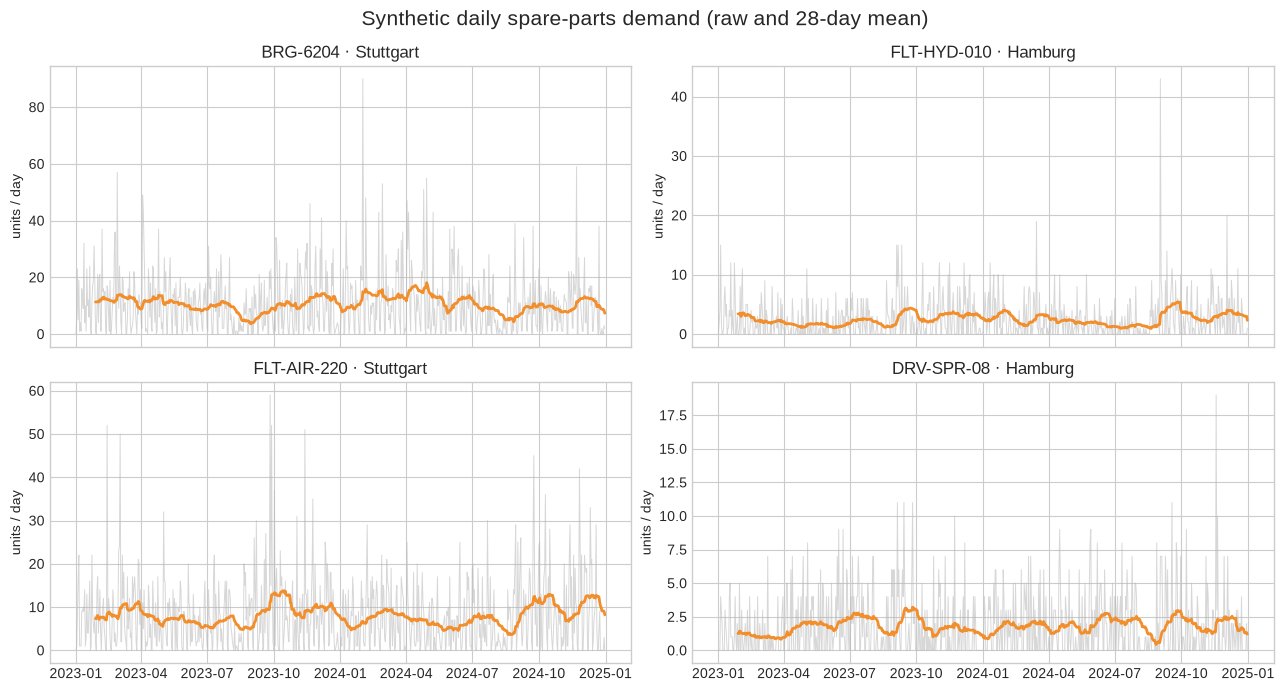

In [5]:
EXAMPLE_SERIES = [
    "BRG-6204 · Stuttgart",
    "FLT-HYD-010 · Hamburg",
    "FLT-AIR-220 · Stuttgart",
    "DRV-SPR-08 · Hamburg",
]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for ax, series_id in zip(axes.flat, EXAMPLE_SERIES):
    sample = panel.loc[panel["series_id"].eq(series_id)].set_index("date")
    ax.plot(sample.index, sample["demand"], color="#B7B7B7", alpha=0.55, linewidth=0.7)
    ax.plot(sample.index, sample["demand"].rolling(28).mean(), color="#F28E2B", linewidth=2)
    ax.set_title(series_id)
    ax.set_ylabel("units / day")
fig.suptitle("Synthetic daily spare-parts demand (raw and 28-day mean)", fontsize=15)
fig.tight_layout()
plt.show()

## Turn the time series into a supervised table

TabPFN is a tabular model, so each row needs to describe one target day. We add:

- calendar and trend features;
- weekly and annual Fourier terms;
- demand lags at operationally useful daily and weekly offsets; and
- shifted rolling statistics over 7 and 28 days.

Every demand-derived feature starts with `shift(1)`. Therefore the row for day *t* never contains demand from day *t* or later.

In [6]:
LAGS = (1, 2, 7, 14, 28, 56)
WINDOWS = (7, 28)
SERIES_KEYS = ["series_id"]


def add_time_series_features(frame):
    result = frame.sort_values(SERIES_KEYS + ["date"]).copy()
    date = result["date"]
    result["day_of_week"] = date.dt.dayofweek
    result["day_of_month"] = date.dt.day
    result["month"] = date.dt.month
    result["day_of_year"] = date.dt.dayofyear
    result["is_weekend"] = date.dt.dayofweek.ge(5).astype(int)
    result["time_index"] = (date - date.min()).dt.days

    for period, harmonics, label in [(7, 1, "week"), (365.25, 2, "year")]:
        for harmonic in range(1, harmonics + 1):
            angle = 2 * np.pi * harmonic * result["time_index"] / period
            result[f"{label}_sin_{harmonic}"] = np.sin(angle)
            result[f"{label}_cos_{harmonic}"] = np.cos(angle)

    grouped = result.groupby(SERIES_KEYS, sort=False, observed=True)["demand"]
    for lag in LAGS:
        result[f"lag_{lag}"] = grouped.shift(lag)

    shifted = grouped.shift(1)
    shifted_grouped = shifted.groupby(result["series_id"], sort=False, observed=True)
    for window in WINDOWS:
        rolling = shifted_grouped.rolling(window, min_periods=window)
        result[f"rolling_mean_{window}"] = rolling.mean().reset_index(level=0, drop=True)
        result[f"rolling_std_{window}"] = rolling.std(ddof=0).reset_index(level=0, drop=True)
        result[f"rolling_median_{window}"] = rolling.median().reset_index(level=0, drop=True)
        result[f"rolling_max_{window}"] = rolling.max().reset_index(level=0, drop=True)
        zeros = shifted.eq(0).astype(float).groupby(result["series_id"], sort=False).rolling(
            window, min_periods=window
        ).mean()
        result[f"zero_share_{window}"] = zeros.reset_index(level=0, drop=True)

    return result


featured = add_time_series_features(panel).dropna().reset_index(drop=True)
featured.filter(regex="^(date|series_id|demand|lag_|rolling_|week_|year_)").head()

,date,demand,series_id,week_sin_1,week_cos_1,year_sin_1,year_cos_1,year_sin_2,year_cos_2,lag_1,lag_2,lag_7,lag_14,lag_28,lag_56,rolling_mean_7,rolling_std_7,rolling_median_7,rolling_max_7,rolling_mean_28,rolling_std_28,rolling_median_28,rolling_max_28
0,2023-02-26,1,BRG-6204 · Hamburg,-1.959435e-15,1.000000,0.821100,0.570784,0.937342,-0.348411,1.0,21.0,1.0,1.0,1.0,0.0,10.000000,9.651055,6.0,28.0,9.500000,8.394301,8.0,36.0
1,2023-02-27,19,BRG-6204 · Hamburg,7.818315e-01,0.623490,0.830797,0.556576,0.924803,-0.380447,1.0,1.0,5.0,36.0,19.0,3.0,10.000000,9.651055,6.0,28.0,9.500000,8.394301,8.0,36.0
2,2023-02-28,5,BRG-6204 · Hamburg,9.749279e-01,-0.222521,0.840248,0.542202,0.911169,-0.412034,19.0,1.0,6.0,5.0,15.0,13.0,12.000000,9.856108,8.0,28.0,9.500000,8.394301,8.0,36.0
3,2023-03-01,6,BRG-6204 · Hamburg,4.338837e-01,-0.900969,0.849450,0.527668,0.896456,-0.443132,5.0,19.0,28.0,12.0,6.0,8.0,11.857143,9.948849,8.0,28.0,9.142857,8.365381,7.0,36.0
4,2023-03-02,11,BRG-6204 · Hamburg,-4.338837e-01,-0.900969,0.858402,0.512978,0.880683,-0.473706,6.0,5.0,8.0,3.0,14.0,20.0,8.714286,7.534953,6.0,21.0,9.142857,8.365381,7.0,36.0


## Hold out the final four weeks

We evaluate 28 consecutive next-day forecasts. On each test day, the previous day's actual demand is assumed to have arrived before the new forecast is made. This rolling-origin setup is appropriate for daily replenishment decisions; it is different from predicting an entire 28-day horizon at once.

Static part, category, and location labels are one-hot encoded so pooled models can distinguish their member series.

In [7]:
TEST_DAYS = 28
cutoff = featured["date"].max() - pd.Timedelta(days=TEST_DAYS - 1)

STATIC_COLUMNS = ["part_id", "category", "location"]
encoded = pd.get_dummies(featured, columns=STATIC_COLUMNS, dtype=float)
# Keep the readable labels for selecting model pools; only their dummy columns are features.
encoded[STATIC_COLUMNS] = featured[STATIC_COLUMNS]
NON_FEATURES = {
    "date", "part_name", "state_code", "series_id", "demand",
    "part_id", "category", "location"
}
FEATURES = [column for column in encoded.columns if column not in NON_FEATURES]

train = encoded.loc[encoded["date"].lt(cutoff)].copy()
test = encoded.loc[encoded["date"].ge(cutoff)].copy()
print(f"Train through {train['date'].max().date()}: {len(train):,} rows")
print(f"Test from {cutoff.date()}: {len(test):,} rows ({TEST_DAYS} per series)")
print(f"Candidate features: {len(FEATURES)}")

Train through 2024-12-03: 7,764 rows
Test from 2024-12-04: 336 rows (28 per series)
Candidate features: 41


## Fit local and grouped TabPFN regressors

The fitting helper is the key comparison. For every local series, product category, or location it:

1. selects that group's training and test rows;
2. removes features that are constant within the group;
3. fills missing numeric values with training medians;
4. fits `TabPFNRegressor` on `log1p(demand)`; and
5. converts predictions back to non-negative unit demand.

We retain at most the latest 300 observations per member series. This gives local models enough recent history while keeping pooled TabPFN contexts compact. Increase `n_estimators` from 2 to 8 or more for a production experiment.

In [8]:
MODEL_KWARGS = dict(
    n_estimators=2,
    device="auto",
    ignore_pretraining_limits=True,
    random_state=SEED,
    show_progress_bar=False,
)
MAX_TRAIN_ROWS_PER_SERIES = 300


def fit_predict_by(group_column, strategy_name):
    predictions = []

    for group_value, group_test in test.groupby(group_column, observed=True, sort=True):
        group_train = train.loc[train[group_column].eq(group_value)].copy()
        group_train = (
            group_train.sort_values("date")
            .groupby("series_id", observed=True, group_keys=False)
            .tail(MAX_TRAIN_ROWS_PER_SERIES)
        )

        usable = [
            column for column in FEATURES
            if group_train[column].notna().any() and group_train[column].nunique(dropna=True) > 1
        ]
        fill_values = group_train[usable].median()
        X_train = group_train[usable].fillna(fill_values).to_numpy(np.float32)
        X_test = group_test[usable].fillna(fill_values).to_numpy(np.float32)
        y_train = np.log1p(group_train["demand"].to_numpy(float))

        model = TabPFNRegressor(**MODEL_KWARGS)
        model.fit(X_train, y_train)
        prediction = np.clip(np.expm1(model.predict(X_test)), 0, None)

        predictions.append(
            group_test[["date", "series_id", "demand"]].assign(
                strategy=strategy_name, prediction=prediction
            )
        )

    return pd.concat(predictions, ignore_index=True)


local_predictions = fit_predict_by("series_id", "Series by series")
category_predictions = fit_predict_by("category", "Product category")
location_predictions = fit_predict_by("location", "Location")
predictions = pd.concat(
    [local_predictions, category_predictions, location_predictions], ignore_index=True
)
predictions.head()

,date,series_id,demand,strategy,prediction
0,2024-12-04,BRG-6204 · Hamburg,7,Series by series,8.251143
1,2024-12-05,BRG-6204 · Hamburg,11,Series by series,7.752102
2,2024-12-06,BRG-6204 · Hamburg,8,Series by series,7.203261
3,2024-12-07,BRG-6204 · Hamburg,1,Series by series,0.864012
4,2024-12-08,BRG-6204 · Hamburg,3,Series by series,0.648311


## Compare the pooling strategies

No pooling strategy is universally best. Local models preserve each series' identity, category models can borrow strength from parts with similar failure or replacement cycles, and location models can learn plant-specific shutdown and utilisation patterns. We report MAE, RMSE, WAPE, and signed bias across the same held-out rows.

In [9]:
def score(group):
    actual = group["demand"].to_numpy(float)
    predicted = group["prediction"].to_numpy(float)
    return pd.Series(
        {
            "MAE": mean_absolute_error(actual, predicted),
            "RMSE": root_mean_squared_error(actual, predicted),
            "WAPE (%)": 100 * np.abs(actual - predicted).sum() / actual.sum(),
            "Bias (%)": 100 * (predicted - actual).sum() / actual.sum(),
        }
    )


metrics = (
    predictions.groupby("strategy", observed=True)
    .apply(score, include_groups=False)
    .sort_values("WAPE (%)")
    .round(2)
)
metrics

,MAE,RMSE,WAPE (%),Bias (%)
strategy,,,,
Location,2.12,3.84,51.69,-18.67
Product category,2.15,3.87,52.35,-18.21
Series by series,2.25,4.01,54.80,-18.51


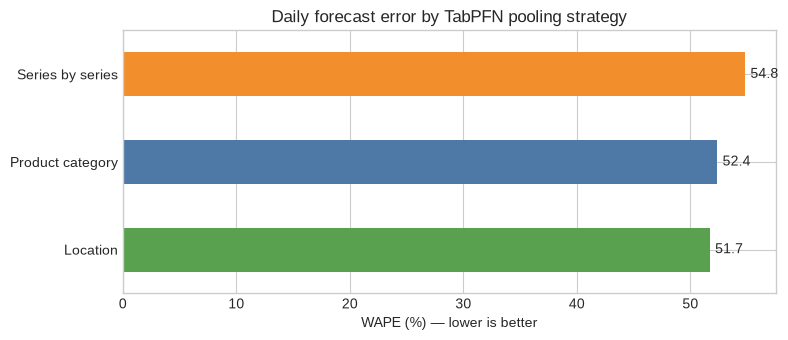

In [10]:
ax = metrics["WAPE (%)"].sort_values().plot.barh(
    figsize=(8, 3.5), color=["#59A14F", "#4E79A7", "#F28E2B"]
)
ax.set_title("Daily forecast error by TabPFN pooling strategy")
ax.set_xlabel("WAPE (%) — lower is better")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=4)
plt.tight_layout()
plt.show()

### Forecast traces for selected parts

Plotting individual series is essential: aggregate metrics can hide systematic over-forecasting of sparse items or missed maintenance peaks. The solid black line is observed demand; colored dashed lines are the three TabPFN strategies during the final 28 days.

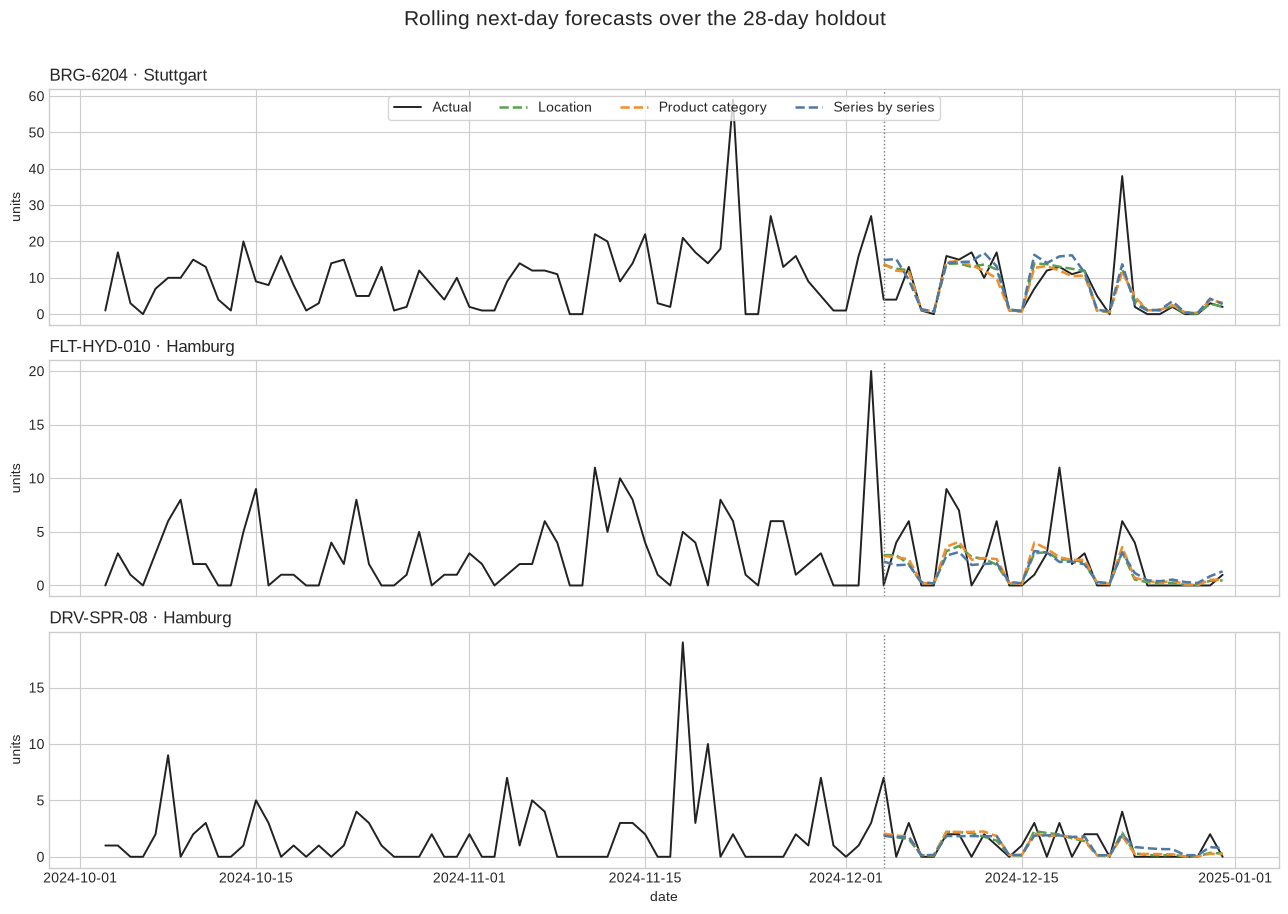

In [11]:
PLOT_SERIES = [
    "BRG-6204 · Stuttgart",
    "FLT-HYD-010 · Hamburg",
    "DRV-SPR-08 · Hamburg",
]
COLORS = {
    "Series by series": "#4E79A7",
    "Product category": "#F28E2B",
    "Location": "#59A14F",
}

fig, axes = plt.subplots(len(PLOT_SERIES), 1, figsize=(13, 9), sharex=True)
history_start = cutoff - pd.Timedelta(days=62)
for ax, series_id in zip(axes, PLOT_SERIES):
    actual = panel.loc[
        panel["series_id"].eq(series_id) & panel["date"].ge(history_start)
    ]
    ax.plot(actual["date"], actual["demand"], color="#222222", linewidth=1.4, label="Actual")
    for strategy, forecast in predictions.loc[predictions["series_id"].eq(series_id)].groupby("strategy"):
        ax.plot(
            forecast["date"], forecast["prediction"],
            color=COLORS[strategy], linestyle="--", linewidth=1.8, label=strategy,
        )
    ax.axvline(cutoff, color="#777777", linestyle=":", linewidth=1)
    ax.set_title(series_id, loc="left")
    ax.set_ylabel("units")
axes[0].legend(ncol=4, frameon=True, loc="upper center")
axes[-1].set_xlabel("date")
fig.suptitle("Rolling next-day forecasts over the 28-day holdout", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

## Diagnose where grouping helps

A global winner does not imply the same choice for every category. The view below breaks WAPE down by product category and helps decide whether routing series to different model pools is worthwhile.

In [12]:
series_metadata = panel[["series_id", "category", "location"]].drop_duplicates()
detailed = predictions.merge(series_metadata, on="series_id", validate="many_to_one")
by_category = (
    detailed.groupby(["category", "strategy"], observed=True)
    .apply(lambda x: 100 * np.abs(x["demand"] - x["prediction"]).sum() / x["demand"].sum(), include_groups=False)
    .unstack("strategy")
    .round(1)
)
by_category

strategy,Location,Product category,Series by series
category,,,
Bearings,44.6,44.9,47.4
Drive,57.5,58.2,63.8
Filters,57.0,58.0,59.1


## Takeaways and production extensions

This pattern turns a collection of daily series into small, related tabular regression tasks. Local TabPFN models are a strong choice when a series has ample history and distinctive dynamics. Category or location pooling is often more useful for sparse series because the model can reuse evidence from related parts. Validate the choice with rolling backtests rather than assuming one grouping will dominate.

For a production spare-parts system, consider adding known-in-advance signals such as planned maintenance orders, shift calendars, installed-base counts, lead times, stock-outs, and promotions. Keep unavailable future information out of feature rows, evaluate several forecast origins, and use a direct-horizon or recursive design when the business needs a fixed multi-day forecast rather than daily next-day updates. Prediction intervals and asymmetric stock-out costs are natural next steps.